In [48]:
# Test mlflow

import mlflow
mlflow.set_tracking_uri("http://ec2-13-61-23-118.eu-north-1.compute.amazonaws.com:5000/")


with mlflow.start_run():
    mlflow.log_param("param1", 17)
    mlflow.log_metric("metric1", 0.90)

🏃 View run unequaled-swan-756 at: http://ec2-13-61-23-118.eu-north-1.compute.amazonaws.com:5000/#/experiments/1/runs/b0ca0b8faefb4cafa23c6c1a43a88e04
🧪 View experiment at: http://ec2-13-61-23-118.eu-north-1.compute.amazonaws.com:5000/#/experiments/1


In [49]:
import pandas as pd
df = pd.read_csv("processed_data.csv")

In [50]:
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


In [51]:
df = df[['clean_comment', 'category']]
df.head()

,clean_comment,category
0,family mormon never tried explain still stare ...,1
1,buddhism much lot compatible christianity espe...,1
2,seriously say thing first get complex explain ...,-1
3,learned want teach different focus goal not wr...,0
4,benefit may want read living buddha living chr...,1


In [52]:
df['clean_comment'] = df['clean_comment'].fillna('')

In [53]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
#Vectorize the comments using Bag of Words (CountVectorizer)
vectorizer = CountVectorizer(max_features=10000)  # Bag of Words model with a limit of 1000 features

X = vectorizer.fit_transform(df['clean_comment']).toarray()
y = df['category']  # Assuming 'sentiment' is the target variable (0 or 1 for binary classification)

In [55]:
X.shape

(36794, 10000)

In [56]:
y

0        1
1        1
2       -1
3        0
4        1
        ..
36789    0
36790    1
36791    0
36792    1
36793    0
Name: category, Length: 36794, dtype: int64

In [57]:
mlflow.set_tracking_uri("http://ec2-13-61-23-118.eu-north-1.compute.amazonaws.com:5000/")

In [58]:
mlflow.set_experiment("RF Baseline")

<Experiment: artifact_location='s3://mlflow-bucket-1807077/1', creation_time=1773359354649, experiment_id='1', last_update_time=1773359354649, lifecycle_stage='active', name='RF Baseline', tags={}>

/Users/rakibmahmud/Library/Python/3.9/lib/python/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
2026/03/13 14:43:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 14:43:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run RandomForest_Baseline_TrainTestSplit at: http://ec2-13-61-23-118.eu-north-1.compute.amazonaws.com:5000/#/experiments/1/runs/1674eb62fbad4ccaa4d5b903216cb4ff
🧪 View experiment at: http://ec2-13-61-23-118.eu-north-1.compute.amazonaws.com:5000/#/experiments/1
Accuracy: 0.6476423427096073


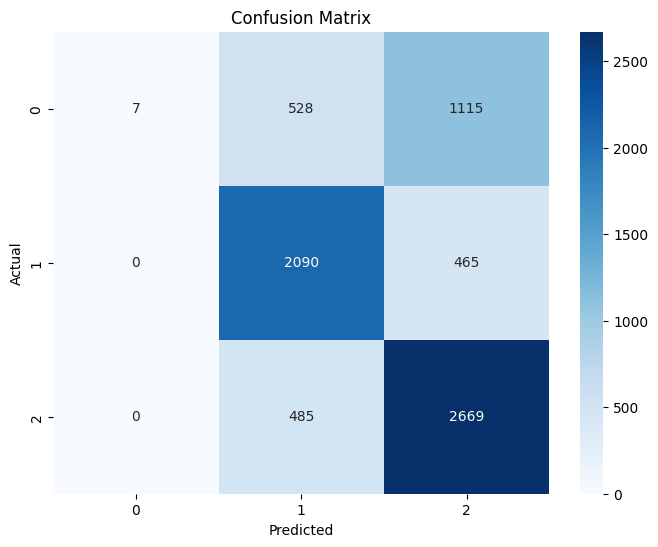

In [59]:
# Step 1: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: Define and train a Random Forest baseline model using a simple train-test split
with mlflow.start_run() as run:

    # Log a description for the run
    mlflow.set_tag("mlflow.runName", "RandomForest_Baseline_TrainTestSplit")
    mlflow.set_tag("experiment_type", "baseline")
    mlflow.set_tag("model_type", "RandomForestClassifier")

    # Add a description
    mlflow.set_tag(
        "description",
        "Baseline RandomForest model for sentiment analysis using Bag of Words"
    )

    # Log parameters for the vectorizer
    mlflow.log_param("vectorizer_type", "CountVectorizer")
    mlflow.log_param("vectorizer_max_features", vectorizer.max_features)

    # Log Random Forest parameters
    n_estimators = 200
    max_depth = 15

    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)

    # Initialize and train the model
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Log metrics for each class and accuracy
    accuracy = accuracy_score(y_test, y_pred)
    mlflow.log_metric("accuracy", accuracy)

    classification_rep = classification_report(y_test, y_pred, output_dict=True)

    for label, metrics in classification_rep.items():
        if isinstance(metrics, dict):  # For precision, recall, f1-score
            for metric, value in metrics.items():
                mlflow.log_metric(f"{label}_{metric}", value)

    # Confusion matrix plot
    conf_matrix = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    # Save and log the confusion matrix plot
    plt.savefig("confusion_matrix.png")
    mlflow.log_artifact("confusion_matrix.png")

    # Log the Random Forest model
    mlflow.sklearn.log_model(model, "random_forest_model")

    # Optionally log the dataset itself (if it's small enough)
    df.to_csv("dataset.csv", index=False)
    mlflow.log_artifact("dataset.csv")

# Display final accuracy
print(f"Accuracy: {accuracy}")

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          -1       1.00      0.00      0.01      1650
           0       0.67      0.82      0.74      2555
           1       0.63      0.85      0.72      3154

    accuracy                           0.65      7359
   macro avg       0.77      0.56      0.49      7359
weighted avg       0.73      0.65      0.57      7359

